In [1]:
library(MASS)
library(leaps)
source("Utils.R")

In [2]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y

hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

### Utilizamos el metodo Forward (utiliza F-Score para elegir variables)

In [15]:
# http://www.science.smith.edu/~jcrouser/SDS293/labs/lab9-r.html

predict.regsubsets = function(object,newdata,id,...){
      form = as.formula(object$call[[2]]) # Extract the formula used when we called regsubsets()
      mat = model.matrix(form,newdata)    # Build the model matrix
      coefi = coef(object,id=id)          # Extract the coefficiants of the ith model
      xvars = names(coefi)                # Pull out the names of the predictors used in the ith model
      mat[,xvars]%*%coefi               # Make predictions using matrix multiplication
}

In [35]:
setSeed()

n = nrow(TRAIN_X)
k = 10

nvmax = 159-n/k
resultados <- matrix(0, nrow = 1, ncol = nvmax)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)

for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    
    forw <- regsubsets(Y~., data =R DF_train, method = "forward", nvmax=nvmax)
    
    for(j in 1:nvmax){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[1, j]] = resultados[[1, j]] + sum((DF_test$Y - Y_pred)^2)
    }
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“158  linear dependencies found”
Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, 

In [46]:
minimo_vars = which.min(resultados)
minimo_vars

[1] 16

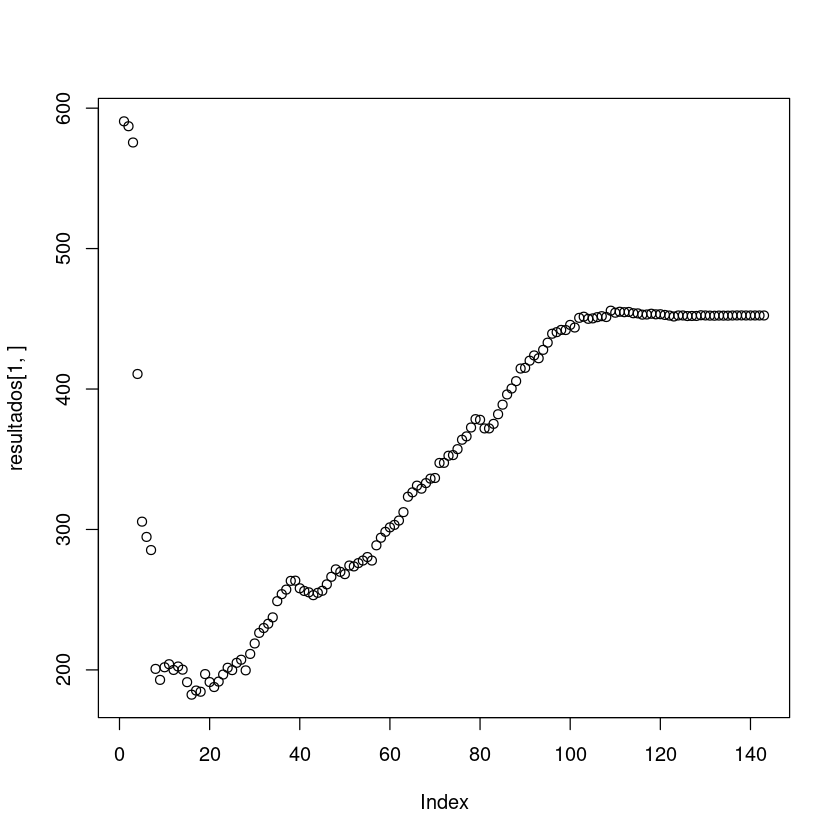

In [45]:
plot(resultados[1,])

##### ANOTACION: 

* Borramos las otras variables que no estén seleccionadas en la iteración 140...

* Nos creamos un data set nuevo con esas 140... y ahora aplicamos forward (nos debería dar literalemtne lo mismo) pero sin el problema de la dimensión (ni correlación) y por ende obtendríamos los gráficos facheros para poner en el informe...


Vemos que para un índice de 16 (eso quiere decir, 16 variables seleccionadas para aplicar forward) se obtiene el valor más chico para el error con validación cruzada

In [47]:
forw <- regsubsets(Y~., data = TRAIN_DF, method = "forward", nvmax=minimo_vars)

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“142  linear dependencies found”


In [92]:
NUEVO_X = TRAIN_DF[, names(which(summary(forw)$which[minimo_vars, ]))[2:(minimo_vars+1)]]

In [85]:
colnames()

[1] "V1"   "V6"   "V8"   "V36"  "V59"  "V70"  "V74"  "V112" "V126" "V133"
[11] "V142" "V143" "V193" "V235" "V242" "V243"

In [98]:
library(glmnet)
library(pracma)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu


Loaded glmnet 4.1-2



In [155]:
setSeed()
n = nrow(TRAIN_X)
k = 10
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Error   =double()
)
indices = obtener_indices_kfold(n, k)

X = NUEVO_X

for(alpha in seq(0, 1, 0.05)){
    for(lambda in c(0, logspace(-10, 4, 15))){
        err = 0
        for(i in indices){
            X_train_scaled = scale(X[-i,])
            Y_train = TRAIN_Y[-i]

            X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                          scale=attr(X_train_scaled, "scaled:scale"))

            Y_test = TRAIN_Y[i]

            model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
            Y_pred = predict(model, X_test_scaled)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(alpha, lambda, err/n))
    }
}
colnames(resultados)  <- c("alpha", "lambda", "Error")

In [156]:
print(which.min(resultados$Error))
print(min(resultados$Error))

[1] 10
[1] 0.6874426


In [160]:
mejores_parametros = resultados[which.min(resultados$Error), ]

Cálculo del error

In [161]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)

X = NUEVO_X

err = 0
for(i in indices){
    X_train_scaled = scale(X[-i,])
    Y_train = TRAIN_Y[-i]

    X_test_scaled = scale(X[i,], center=attr(X_train_scaled, "scaled:center"),
                  scale=attr(X_train_scaled, "scaled:scale"))

    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(err)

[1] 0.7036352


Obtener CP, RSS, R^2, R^2Adj. Sea a mano o con lo que fuese